[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcinkieruzel/JAK_UCZA_SIE_MODELE_AI/blob/main/simple_example.ipynb)

# Jak uczą się modele AI? Wyjaśnienie na prostym przykładzie!

## Gradient Descent — interaktywny przykład na regresji liniowej

W tym notebooku zobaczymy **od podstaw**, jak działa algorytm **gradient descent (spadek wzdłuż gradientu)**,
używając najprostszego możliwego modelu: regresji liniowej z **jedną cechą**. Używamy prostego przykładu ale jego zastosowanie jest uniwersalne i aplikuje się podobnie także w sieciach neuronowych i dużych modelach językowych LLM.

### Pytanie badawcze
> *Czy na podstawie liczby godzin spędzonych na nauce można przewidzieć wynik egzaminu?*

Mamy 200 studentów (dane znajdują się w plik csv), dla każdego znamy `hours_studied` (godziny nauki) i `exam_score` (wynik egzaminu).
Chcemy znaleźć prostą $\;\hat{y} = a \cdot x + b\;$, która **najlepiej** opisuje tę relację.

### Intuicja gradient descent

Wyobraź sobie, że stoisz we mgle na zboczu góry i chcesz zejść do doliny.
Nie widzisz dna, ale czujesz, w którą stronę teren opada najmocniej — i robisz mały krok w tym kierunku.
Powtarzasz to wiele razy.

To dokładnie robi gradient descent: w każdej iteracji oblicza **gradient** funkcji kosztu
(czyli „w którą stronę rośnie najszybciej") i robi krok w **przeciwną** stronę.

### Jeszcze jedna prosta i trochę zabawna intuicja — historia Jasia

- **Nauczyciel** podaje Jasiowi wzór regresji liniowej $\;y = a x + b\;$ oraz zbiór danych (taki sam, jak ten poniżej z wynikami egzaminów i czasem nauki). Aby przewidzieć $y$, trzeba znać współczynniki $a$ i $b$. Pyta więc Jasia: *„Ile powinny wynosić $a$ i $b$?"* \(w istocie a = 2, b = 20\)
- **Jaś** nie zna analitycznego wzoru (regresję najczęściej liczy się metodą najmniejszych kwadratów — MNK), więc postanawia po prostu strzelać: $a = 50$, $b = 80$. Wynik jest oczywiście fatalny.
- **Nauczyciel** trochę podpowiada: *„$b$ to będzie 20, skup się na $a$."*
- I tu z pomocą niewiedzy Jasia przychodzi wrodzona inteligencja. Myśli: *„Skoro 50 było zdecydowanie za dużo, spróbuję mniejszej liczby."* Odpowiada: $a = 20$.
- **Nauczyciel**: *„Lepiej, ale wciąż daleko. Masz jeszcze dwie szanse."*
- **Jaś** myśli: *„Skoro 20 to wciąż za dużo, spróbuję jeszcze mniejszej liczby."* Odpowiada: $a = 4$.
- **Nauczyciel**: *„Bliżej, ale wciąż źle, Jasiu. Ostatnia szansa."*
- **Jaś**: *„Skoro 4 nadal za dużo, to może 2?"* Odpowiada: $a = 2$.
- **Nauczyciel**: *„Trafione!"*

Przykład jest trywialny i mocno uproszczony, ale w gruncie rzeczy **dobrze oddaje zasadę działania gradient descent**:
szukając odpowiednich współczynników (wag), zaczynamy od losowej wartości, sprawdzamy, **jak bardzo** i **w którą stronę** się pomyliliśmy, a następnie robimy kolejny „strzał" — i tak aż do wyeliminowania albo zminimalizowania błędu.

Różnica polega na tym, że Jaś korygował się intuicyjnie, a gradient descent robi to **automatycznie i precyzyjnie** — wielkość i kierunek poprawki wyliczane są z pochodnej funkcji kosztu. W modelach sieci neuronowych zmiennych (wag) do „zgadnięcia" są zaś często **miliony**, a mimo to ten sam mechanizm działa równie dobrze.

Na tym właśnie polega uniwersalizm współczesnych metod uczenia maszynowego — w odróżnieniu od popularnych w latach 80. **systemów eksperckich**. Dzisiejsze podejścia uczą się wykrywać prawidłowości bezpośrednio w danych (przy pomocy uniwersalnych algorytmów, takich jak gradient descent) i na tej podstawie przewidywać poprawne odpowiedzi. Systemy eksperckie próbowały odwrotnie: ręcznie zakodować wiedzę ekspertów w postaci reguł „jeśli–to" — co zawsze okazywało się **niewystarczające** i bardzo skomplikowane w utrzymaniu.

Zabawa w "strzelanie" wag może się czasem wydawać niezbyt inteligentna. Współczesne duże modele językowe LLM są w gruncie rzeczy nakierowane na "zgadywanie" następnego, najbardziej prawdopodobnego słowa (tokenu) w sekwencji. Dla wielu to więc tylko iluzja inteligencji.

Zobaczmy jak na ten argument odpowiada Jerry Kaplan, teoretyk AI i autor książki "Generatywna AI. Wszystko, co warto wiedzieć".

"Stwierdzenie, że LLM nie są inteligentne, ponieważ po prostu wybierają następne słowo w sekwencji, jest jak powiedzenie, że pianiści nie są artystami, ponieważ po prostu wybierają sekwencje klawiszy na klawiaturze fortepianu. Magia polega oczywiście na tym, w jaki sposób sekwencje są tworzone."

„Muzyka jest ukrytą czynnością arytmetyczną duszy, która nie zdaje sobie sprawy, że liczy.”
— Gottfried Wilhelm Leibniz

Jak udawadniają duże modele językowe – sam język jest też po części matematyką.

Przejdźmy teraz do konkretów i spróbujmy obliczyć współczynniki regresji liniowej przy pomocy gradient descent.

## 1. Wczytanie i eksploracja danych

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

CSV_URL = "https://raw.githubusercontent.com/marcinkieruzel/JAK_UCZA_SIE_MODELE_AI/refs/heads/main/student_exam_scores.csv"
csv_path = "student_exam_scores.csv" if os.path.exists("student_exam_scores.csv") else CSV_URL
df = pd.read_csv(csv_path)
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [131]:
df[["hours_studied", "exam_score"]].describe().round(2)

,hours_studied,exam_score
count,200.00,200.00
mean,6.33,33.96
std,3.23,6.79
min,1.00,17.10
25%,3.50,29.50
50%,6.15,34.05
75%,9.00,38.75
max,12.00,51.30


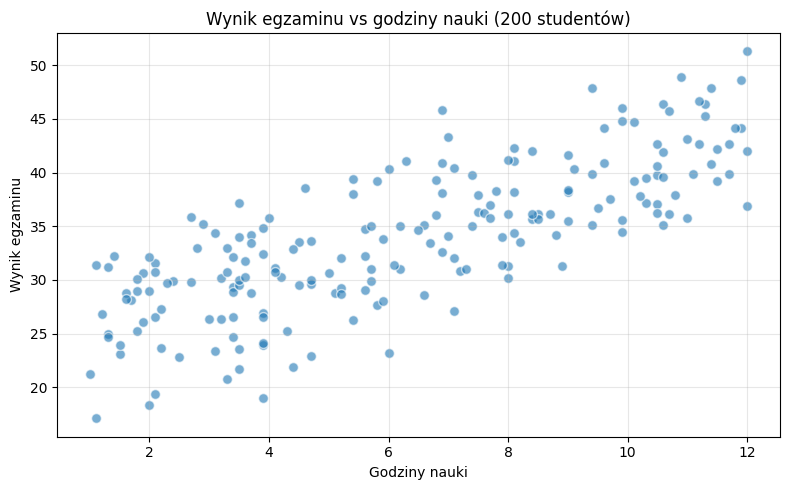

In [132]:
X = df["hours_studied"].values.astype(float)
y = df["exam_score"].values.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, alpha=0.6, edgecolor="white", s=50)
ax.set_xlabel("Godziny nauki")
ax.set_ylabel("Wynik egzaminu")
ax.set_title("Wynik egzaminu vs godziny nauki (200 studentów)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Widać wyraźną **dodatnią zależność** — więcej godzin nauki → wyższy wynik.
Dane układają się dość liniowo, więc model $\hat{y} = a x + b$ ma sens.

Gdybyśmy sobie zadali pytanie – czym jest regresja liniowa. Odpowiedz mogłaby wyglądać mniej więcej tak – to linia prosta która przebiega możliwie najbliżej punktów na wykresie. Kiedy wyznaczymy taką linię będzemy w stanie przewidywać (z dużą dozą prawdopodobieństwa) jaki otrzymamy wynik, zakładając określony czas na naukę. Skąd jednak wiemy co to znaczy, że linia przebiega najbliżej punktów i jak to obliczyć?


## 2. Model i funkcja kosztu

**Model** (regresja liniowa, 1 cecha):
$$\hat{y}_i \;=\; a \cdot x_i + b$$

**Funkcja kosztu — błąd średniokwadratowy (MSE):**
$$L(a, b) \;=\; \frac{1}{n}\sum_{i=1}^{n} \bigl(\hat{y}_i - y_i\bigr)^2
\;=\; \frac{1}{n}\sum_{i=1}^{n} \bigl(a x_i + b - y_i\bigr)^2$$

Im mniejsze $L$, tym lepsze dopasowanie. Naszym celem jest **znaleźć takie $(a, b)$, dla których $L$ jest najmniejsze.**


### Co tak naprawdę oznaczają $a$ i $b$?

Prosta $\hat{y} = a x + b$ ma **dwa stopnie swobody** — możemy ją dowolnie przesuwać i obracać, manipulując tymi dwoma liczbami. Każda z nich ma jasną interpretację geometryczną i dziedzinową.

#### 🔹 $a$ — **nachylenie** (slope, współczynnik kierunkowy)

Mówi, **o ile zmieni się $y$, gdy $x$ wzrośnie o 1**. Matematycznie to pochodna prostej:
$$a = \frac{\Delta y}{\Delta x} = \frac{\hat{y}(x+1) - \hat{y}(x)}{1}$$

W naszych danych $a$ odpowiada na pytanie: **„O ile punktów wzrośnie przewidywany wynik egzaminu za każdą dodatkową godzinę nauki?"**

- $a > 0$ → prosta rośnie (im więcej $x$, tym większe $y$)
- $a < 0$ → prosta opada (więcej $x$ → mniejsze $y$)
- $a = 0$ → prosta pozioma (model mówi, że $x$ nic nie wnosi)
- $|a|$ duże → strome zbocze, mocna zależność; $|a|$ małe → łagodne nachylenie

#### 🔹 $b$ — **wyraz wolny** (intercept, przesunięcie)

To wartość $\hat{y}$, gdy $x = 0$ — czyli **miejsce, w którym prosta przecina oś pionową**:
$$b = \hat{y}(0) = a \cdot 0 + b$$

W naszych danych $b$ to przewidywany wynik egzaminu dla **studenta, który nie uczył się ani godziny**. (Uwaga: to ekstrapolacja poza zakres danych — fizycznie może nie mieć sensu, ale matematycznie definiuje, gdzie „startuje" prosta.)

Zmiana $b$ **przesuwa całą prostą w górę/dół**, nie zmieniając jej kąta nachylenia.

#### Razem $(a, b)$ jednoznacznie określają prostą

Dwie liczby wystarczą — to dlatego model jest taki prosty i taki dobry do nauki gradient descent.
Dla regresji wielowymiarowej (więcej cech) parametrów będzie więcej (jeden $a$ na każdą cechę plus $b$), ale **mechanika gradient descent się nie zmienia**.


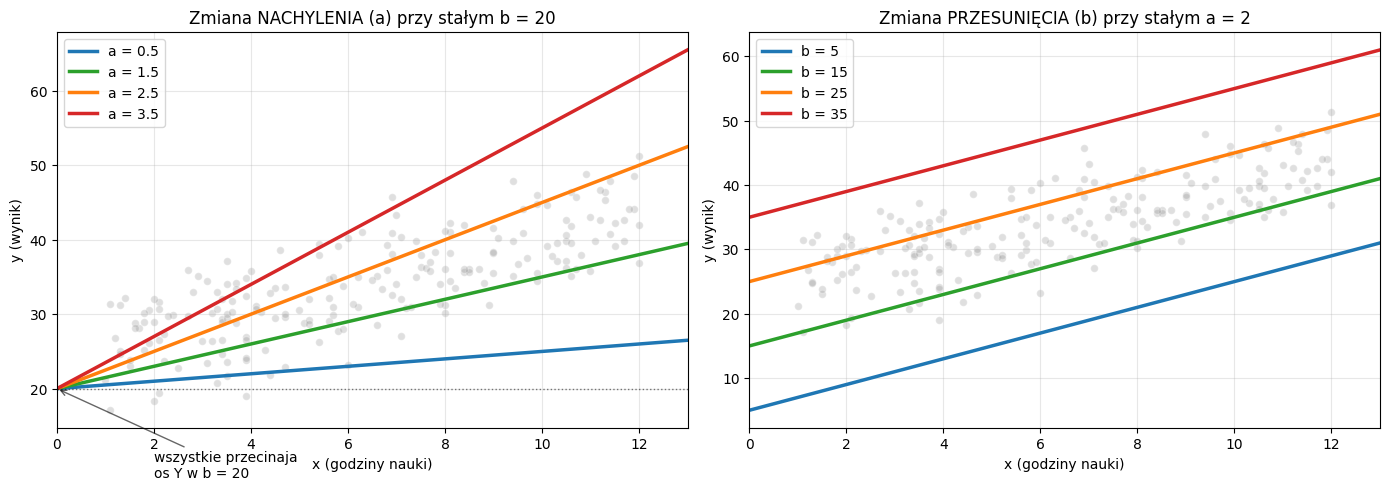

In [133]:
# Wizualizacja: co robi zmiana a, a co zmiana b?
X_demo = df["hours_studied"].values.astype(float)
y_demo = df["exam_score"].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_line = np.linspace(0, 13, 100)

# (1) Zmiana a (przy stalym b = 20)
axes[0].scatter(X_demo, y_demo, alpha=0.25, edgecolor="white", s=30, color="gray")
for a_val, color in zip([0.5, 1.5, 2.5, 3.5], ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
    axes[0].plot(x_line, a_val * x_line + 20, linewidth=2.5, color=color, label=f"a = {a_val}")
axes[0].axhline(20, color="black", linestyle=":", linewidth=1, alpha=0.5)
axes[0].annotate(
    "wszystkie przecinaja\nos Y w b = 20",
    xy=(0, 20),
    xytext=(2, 8),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="black", alpha=0.6),
)
axes[0].set_xlabel("x (godziny nauki)")
axes[0].set_ylabel("y (wynik)")
axes[0].set_title("Zmiana NACHYLENIA (a) przy stałym b = 20")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 13)

# (2) Zmiana b (przy stalym a = 2)
axes[1].scatter(X_demo, y_demo, alpha=0.25, edgecolor="white", s=30, color="gray")
for b_val, color in zip([5, 15, 25, 35], ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
    axes[1].plot(x_line, 2.0 * x_line + b_val, linewidth=2.5, color=color, label=f"b = {b_val}")
axes[1].set_xlabel("x (godziny nauki)")
axes[1].set_ylabel("y (wynik)")
axes[1].set_title("Zmiana PRZESUNIĘCIA (b) przy stałym a = 2")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 13)

plt.tight_layout()
plt.show()

**Lewy panel**: wszystkie linie przechodzą przez ten sam punkt na osi Y ($y = 20$), ale obracają się wokół niego — to czysta zmiana nachylenia $a$.

**Prawy panel**: wszystkie linie mają to samo nachylenie (są równoległe), ale każda jest przesunięta w górę/dół — to czysta zmiana $b$.

Gradient descent będzie majstrował **przy obu jednocześnie**, szukając tej jednej kombinacji $(a, b)$, dla której prosta najlepiej leży „w środku chmury" punktów.


In [134]:
def predict(x, a, b):
    return a * x + b


def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

### Policzmy MSE krok po kroku na 3 punktach

Żeby było jasne, co MSE faktycznie robi, weźmy **3 zmyślonych studentów** i policzmy wszystko ręcznie.

| student | $x_i$ (godziny) | $y_i$ (wynik) |
|:-:|:-:|:-:|
| 1 | 2 | 25 |
| 2 | 5 | 32 |
| 3 | 8 | 41 |

Strzelamy: $a = 2$, $b = 20$. Czyli model mówi: $\hat{y} = 2x + 20$.

Dla każdego studenta liczymy:
1. **Predykcja**: $\hat{y}_i = 2 x_i + 20$
2. **Błąd**: $\hat{y}_i - y_i$
3. **Błąd do kwadratu**: $(\hat{y}_i - y_i)^2$

Na końcu uśredniamy kwadraty błędów — to właśnie MSE.


In [135]:
# Mały, ręcznie wymyślony zbiór
x_toy = np.array([2.0, 5.0, 8.0])
y_toy = np.array([25.0, 32.0, 41.0])

a, b = 2.0, 20.0

y_pred = predict(x_toy, a, b)
error = y_pred - y_toy
sq_error = error**2

# Wyswietlamy tabelke krok po kroku
print(f"Model: y_hat = {a}*x + {b}\n")
print(f"{'i':>2} | {'x_i':>5} | {'y_i':>5} | {'y_hat':>6} | {'blad':>6} | {'blad^2':>7}")
print("-" * 50)
for i, (xi, yi, yp, e, se) in enumerate(zip(x_toy, y_toy, y_pred, error, sq_error), start=1):
    print(f"{i:>2} | {xi:>5.1f} | {yi:>5.1f} | {yp:>6.1f} | {e:>+6.1f} | {se:>7.2f}")

print("-" * 50)
print(f"Suma kwadratow bledow: {sq_error.sum():.2f}")
print(f"Liczba probek (n): {len(x_toy)}")
print(f"MSE = suma / n = {sq_error.sum():.2f} / {len(x_toy)} = {sq_error.mean():.3f}")
print()
print(f"Sprawdzenie funkcja mse(): {mse(y_toy, y_pred):.3f}  ✓")

Model: y_hat = 2.0*x + 20.0

 i |   x_i |   y_i |  y_hat |   blad |  blad^2
--------------------------------------------------
 1 |   2.0 |  25.0 |   24.0 |   -1.0 |    1.00
 2 |   5.0 |  32.0 |   30.0 |   -2.0 |    4.00
 3 |   8.0 |  41.0 |   36.0 |   -5.0 |   25.00
--------------------------------------------------
Suma kwadratow bledow: 30.00
Liczba probek (n): 3
MSE = suma / n = 30.00 / 3 = 10.000

Sprawdzenie funkcja mse(): 10.000  ✓


Zobaczmy to samo na wykresie. Każdy **szary odcinek pionowy** to różnica między prawdziwym $y_i$ a tym, co przewiduje nasz model $\hat{y}_i$ — czyli właśnie **błąd**, którego kwadrat trafia do MSE.


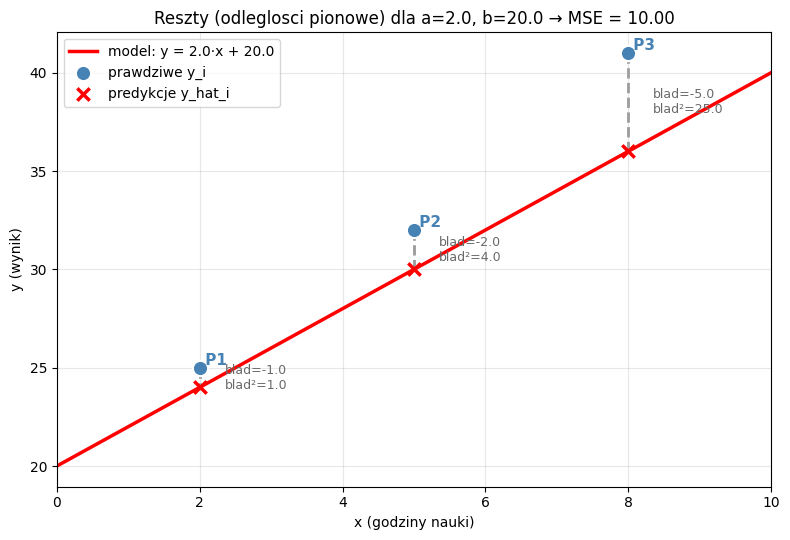

In [136]:
fig, ax = plt.subplots(figsize=(8, 5.5))

# Prosta regresji
x_line = np.linspace(0, 10, 100)
ax.plot(
    x_line,
    predict(x_line, a, b),
    color="red",
    linewidth=2.5,
    label=f"model: y = {a}·x + {b}",
    zorder=2,
)

# Pionowe linie reszt + opis bledu i kwadratu bledu
for xi, yi, yp, e, se in zip(x_toy, y_toy, y_pred, error, sq_error):
    ax.plot([xi, xi], [yi, yp], color="gray", linewidth=2, linestyle="--", alpha=0.8, zorder=1)
    # Annotation w polowie odcinka
    y_mid = (yi + yp) / 2
    ax.annotate(
        f"blad={e:+.1f}\nblad²={se:.1f}",
        xy=(xi, y_mid),
        xytext=(xi + 0.35, y_mid),
        fontsize=9,
        color="dimgray",
        va="center",
    )

# Punkty danych
ax.scatter(
    x_toy,
    y_toy,
    s=120,
    color="steelblue",
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
    label="prawdziwe y_i",
)
# Predykcje na prostej
ax.scatter(
    x_toy, y_pred, s=80, color="red", marker="x", linewidth=2.5, zorder=3, label="predykcje y_hat_i"
)

# Etykiety punktow
for i, (xi, yi) in enumerate(zip(x_toy, y_toy), start=1):
    ax.annotate(f" P{i}", (xi, yi), fontsize=11, fontweight="bold", color="steelblue", va="bottom")

ax.set_xlabel("x (godziny nauki)")
ax.set_ylabel("y (wynik)")
ax.set_title(f"Reszty (odleglosci pionowe) dla a={a}, b={b} → MSE = {sq_error.mean():.2f}")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

**Sprawdź sam:** spróbuj zmienić $a$ i $b$ powyżej — zobaczysz, że jeśli linia lepiej pasuje do punktów, kolumna `blad^2` ma mniejsze wartości, a MSE spada. To dokładnie to, co algorytm gradient descent będzie próbował minimalizować.


### A można to policzyć **bez** gradient descent? \(Jak policzyłby regresję Jaś gdyby znał metodę najmniejszych kwadratów\).

**Tak — i dla tego konkretnego modelu (regresja liniowa + MSE) jest na to wzór analityczny.**

To tzw. **metoda najmniejszych kwadratów** (least squares). Z warunku $\partial L/\partial a = 0$ i $\partial L/\partial b = 0$ (zerowanie gradientu = punkt minimum dla funkcji wypukłej) wyprowadza się:

$$a^* \;=\; \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\;=\; \frac{\mathrm{cov}(x, y)}{\mathrm{var}(x)}$$

$$b^* \;=\; \bar{y} - a^* \cdot \bar{x}$$

gdzie $\bar{x}$, $\bar{y}$ to średnie. Wzór ten daje **dokładne** optymalne $(a, b)$ w jednym kroku, bez żadnej iteracji.


In [137]:
# Rozwiazanie zamkniete (closed-form / least squares) dla naszych danych
x_mean = X.mean()
y_mean = y.mean()

a_closed = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b_closed = y_mean - a_closed * x_mean

mse_closed = mse(y, predict(X, a_closed, b_closed))

print("Rozwiazanie zamkniete (least squares):")
print(f" a* = {a_closed:.4f}")
print(f" b* = {b_closed:.4f}")
print(f" MSE = {mse_closed:.4f}")
print()
print("To jest GLOBALNE minimum — zadne inne (a, b) nie da mniejszego MSE.")
print("Pozniej gradient descent dojdzie dokladnie do tych samych wartosci.")

Rozwiazanie zamkniete (least squares):
 a* = 1.6341
 b* = 23.6184
 MSE = 18.1937

To jest GLOBALNE minimum — zadne inne (a, b) nie da mniejszego MSE.
Pozniej gradient descent dojdzie dokladnie do tych samych wartosci.


### Skoro mamy gotowy wzór, **po co w ogóle uczyć się gradient descent**?

Bardzo dobre pytanie. Cztery powody, dla których ten wzór działa tylko *tutaj*, a gradient descent jest narzędziem uniwersalnym:

#### 1. 🔒 Wzór działa **tylko** dla regresji liniowej z MSE

Forma zamknięta wynika z faktu, że gradient $L(a, b)$ jest **liniowy** w parametrach. Wystarczy, że:
- zmienisz funkcję kosztu (np. na cross-entropy w klasyfikacji) → wzoru już nie ma,
- dodasz nieliniowość do modelu (np. $\hat{y} = \sigma(a x + b)$ jak w regresji logistycznej) → wzoru już nie ma,
- użyjesz sieci neuronowej → wzoru **nigdy** nie będzie.

Gradient descent działa wszędzie tam, gdzie umiesz policzyć pochodne — czyli praktycznie zawsze.

#### 2. 💸 Koszt obliczeniowy przy wielu cechach

W wielu wymiarach forma zamknięta wymaga odwrócenia macierzy $X^T X$ rozmiaru $p \times p$, co kosztuje $O(p^3)$. Dla $p = 10\,000$ cech (zwykła sieć dostaje miliony) — niewykonalne. Gradient descent kosztuje tylko $O(np)$ na iterację.

#### 3. 📦 Duże zbiory danych

Forma zamknięta wymaga przepuszczenia **wszystkich** danych przez pamięć naraz. Dla zbiorów typu ImageNet (>1M obrazów) to się nie zmieści. Wariant gradient descent — **stochastic gradient descent (SGD)** — uczy się po małych porcjach (batchach), więc przerobi dowolnie duży zbiór.

#### 4. 🧠 Gradient descent to **wspólny język** całego deep learningu

Każda biblioteka ML (PyTorch, TensorFlow, JAX) jest zbudowana wokół gradient descent + autograd. Naucz się jednego algorytmu, używaj go wszędzie: regresja, klasyfikacja, transformery, GAN-y, modele dyfuzyjne — pod spodem zawsze ten sam mechanizm.

#### Podsumowując

> Dla regresji liniowej z MSE wzór analityczny jest **szybszy i dokładniejszy** niż GD. Ale realne problemy ML to nie regresja liniowa, więc uczymy się GD na tym najprostszym przykładzie, gdzie możemy **porównać wynik z prawdziwym optimum** i być pewni, że algorytm działa poprawnie.

W następnych sekcjach zaimplementujemy GD od zera i zobaczymy, że dochodzi dokładnie do tego samego $(a^*, b^*)$, który właśnie policzyliśmy wzorem.


## 3. Ręczne strzelanie

Zanim odpalimy algorytm, spróbujmy „na oko" znaleźć dobre $a$ i $b$. Dokładnie tak jak to robił Jaś.


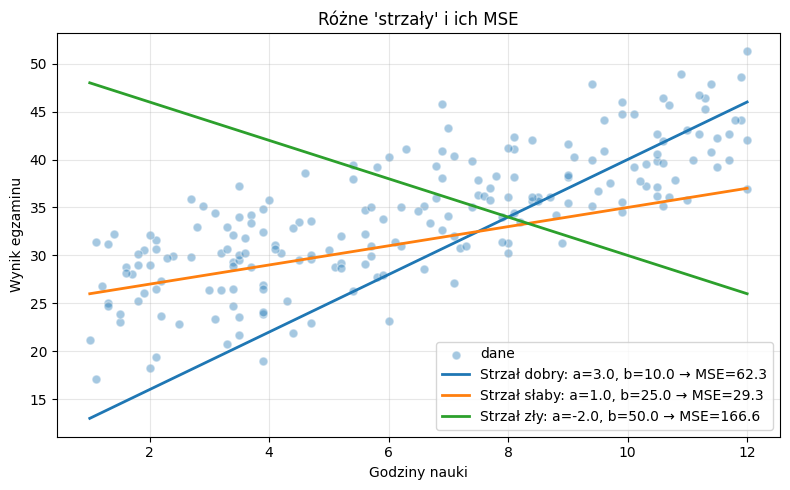

In [138]:
guesses = [
    ("Strzał dobry", 3.0, 10.0),
    ("Strzał słaby", 1.0, 25.0),
    ("Strzał zły", -2.0, 50.0),
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X, y, alpha=0.4, edgecolor="white", s=40, label="dane")

x_line = np.linspace(X.min(), X.max(), 100)
for name, a, b in guesses:
    y_pred = predict(X, a, b)
    loss = mse(y, y_pred)
    ax.plot(
        x_line, predict(x_line, a, b), label=f"{name}: a={a}, b={b} → MSE={loss:.1f}", linewidth=2
    )

ax.set_xlabel("Godziny nauki")
ax.set_ylabel("Wynik egzaminu")
ax.set_title("Różne 'strzały' i ich MSE")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 🎯 Teraz Twoja kolej — pobaw się suwakami

Spróbuj sam znaleźć dobre $a$ (nachylenie) i $b$ (przesunięcie). Linia będzie się aktualizować w czasie rzeczywistym, a MSE pokaże Ci, jak blisko optimum jesteś.

**Wskazówka:** najlepsze dopasowanie ma MSE w okolicach **18**. Uda Ci się tam dojść ręcznie?


In [ ]:
from ipywidgets import interact, FloatSlider


def manual_guess(a=2.0, b=20.0):
    y_pred = predict(X, a, b)
    loss = mse(y, y_pred)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(X, y, alpha=0.4, edgecolor="white", s=40, label="dane")

    x_line = np.linspace(X.min(), X.max(), 100)
    ax.plot(
        x_line, predict(x_line, a, b), color="red", linewidth=2.5, label=f"y = {a:.2f}·x + {b:.2f}"
    )

    # Narysuj "reszty" (błędy) jako pionowe szare kreski — dydaktycznie pokazuje, co MSE mierzy
    for xi, yi in zip(X, y):
        ax.plot([xi, xi], [yi, predict(xi, a, b)], color="gray", alpha=0.25, linewidth=0.8)

    ax.set_xlabel("Godziny nauki")
    ax.set_ylabel("Wynik egzaminu")
    ax.set_title(f"Twój strzał: a={a:.2f}, b={b:.2f}  →  MSE = {loss:.2f}")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


interact(
    manual_guess,
    a=FloatSlider(value=2.0, min=-3.0, max=8.0, step=0.1, description="a"),
    b=FloatSlider(value=20.0, min=0.0, max=50.0, step=0.5, description="b"),
)

interactive(children=(FloatSlider(value=2.0, description='a', max=8.0, min=-3.0), FloatSlider(value=20.0, desc…

<function __main__.manual_guess(a=2.0, b=20.0)>

Dobry strzał ma MSE rzędu kilkudziesięciu, zły — kilkuset.
Ale jak znaleźć **najlepszy** $(a, b)$ automatycznie? Najpierw zobaczmy, jak wygląda funkcja kosztu.


## 4. Powierzchnia funkcji kosztu

Funkcja $L(a, b)$ to **paraboloida** (zawsze tak jest dla MSE z modelem liniowym).
Ma jedno minimum globalne — to magiczny punkt, do którego dążymy.


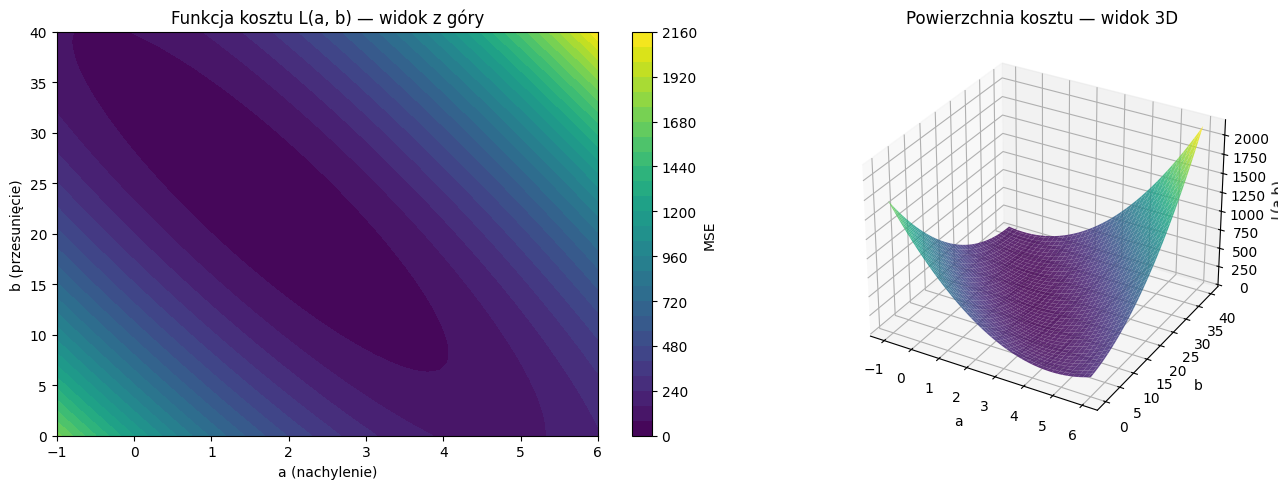

In [140]:
a_grid = np.linspace(-1, 6, 80)
b_grid = np.linspace(0, 40, 80)
A, B = np.meshgrid(a_grid, b_grid)

# Wektoryzacja: liczymy MSE dla każdej pary (a, b)
loss_surface = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        loss_surface[i, j] = mse(y, predict(X, A[i, j], B[i, j]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kontury
cs = axes[0].contourf(A, B, loss_surface, levels=30, cmap="viridis")
axes[0].set_xlabel("a (nachylenie)")
axes[0].set_ylabel("b (przesunięcie)")
axes[0].set_title("Funkcja kosztu L(a, b) — widok z góry")
plt.colorbar(cs, ax=axes[0], label="MSE")

# 3D powierzchnia
ax3d = fig.add_subplot(1, 2, 2, projection="3d")
ax3d.plot_surface(A, B, loss_surface, cmap="viridis", alpha=0.85, edgecolor="none")
ax3d.set_xlabel("a")
ax3d.set_ylabel("b")
ax3d.set_zlabel("L(a,b)")
ax3d.set_title("Powierzchnia kosztu — widok 3D")

# Usuwamy drugi (pusty) subplot
axes[1].remove()
plt.tight_layout()
plt.show()

Widać klasyczną „misę". Gradient descent to schodzenie po tej powierzchni krok po kroku aż do dna.

Możemy ją sobie tak ładnie wyobrazić tylko dlatego, że mamy zaledwie **dwa parametry** do „zgadnięcia" — $a$ i $b$. Razem z osią MSE daje to trzy wymiary, w sam raz dla ludzkiej wyobraźni. W modelach z wieloma wagami (sieci neuronowe mają ich często miliony) powierzchnia kosztu żyje w przestrzeni o **setkach tysięcy wymiarów** — wizualnie nie sposób jej już przedstawić. Matematyka działa jednak identycznie: gradient descent po prostu robi krok „w dół" w **każdym** z tych wymiarów naraz.

## 5. Wyprowadzenie gradientów

Liczymy pochodne cząstkowe $L(a, b)$ względem $a$ i $b$ (różniczkujemy funkcję kosztu po obu parametrach):

$$\frac{\partial L}{\partial a} \;=\; \frac{2}{n}\sum_{i=1}^{n} (a x_i + b - y_i)\, x_i$$

$$\frac{\partial L}{\partial b} \;=\; \frac{2}{n}\sum_{i=1}^{n} (a x_i + b - y_i)$$

Wektor $\bigl(\partial L/\partial a,\; \partial L/\partial b\bigr)$ to **gradient** — wskazuje kierunek
najszybszego **wzrostu** $L$. Aby $L$ malało, idziemy w **przeciwną** stronę:

$$a \;\leftarrow\; a - \eta \cdot \frac{\partial L}{\partial a}, \qquad
b \;\leftarrow\; b - \eta \cdot \frac{\partial L}{\partial b}$$

gdzie $\eta$ (learning rate, **tempo uczenia**) to wielkość kroku.


## 6. Implementacja gradient descent

**Mały trik dydaktyczny — standaryzacja $x$.**
Bez niej, gdy $x \in [1, 12]$, sumy w gradiencie są duże i trzeba bardzo małego $\eta$ (np. $10^{-4}$),
żeby algorytm nie „wybuchł". Po standaryzacji ($x' = (x - \mu)/\sigma$) $\eta \approx 0{,}05$ działa pięknie
i lepiej widać, co robi algorytm. To **standardowa praktyka** w ML.


In [141]:
# Standaryzacja X
X_mean, X_std = X.mean(), X.std()
X_std_scaled = (X - X_mean) / X_std


def gradient_descent(x, y, lr=0.05, n_iter=100, a0=0.0, b0=0.0):
    # Klasyczny batch gradient descent dla regresji liniowej y = a*x + b.
    # Zwraca (a, b, history), gdzie history to lista (a_i, b_i, loss_i) z kazdej iteracji.
    a, b = float(a0), float(b0)
    n = len(x)
    history = [(a, b, mse(y, predict(x, a, b)))]

    for _ in range(n_iter):
        y_pred = predict(x, a, b)
        error = y_pred - y
        grad_a = (2.0 / n) * np.sum(error * x)
        grad_b = (2.0 / n) * np.sum(error)
        a -= lr * grad_a
        b -= lr * grad_b
        history.append((a, b, mse(y, predict(x, a, b))))

    return a, b, history


a_opt, b_opt, hist = gradient_descent(X_std_scaled, y, lr=0.05, n_iter=200, a0=0.0, b0=0.0)
print(f"Po 200 iteracjach (na zestandaryzowanym X):")
print(f"  a = {a_opt:.3f}")
print(f"  b = {b_opt:.3f}")
print(f"  MSE = {hist[-1][2]:.3f}")

Po 200 iteracjach (na zestandaryzowanym X):
  a = 5.261
  b = 33.955
  MSE = 18.194


## 7. Wizualizacja trajektorii uczenia

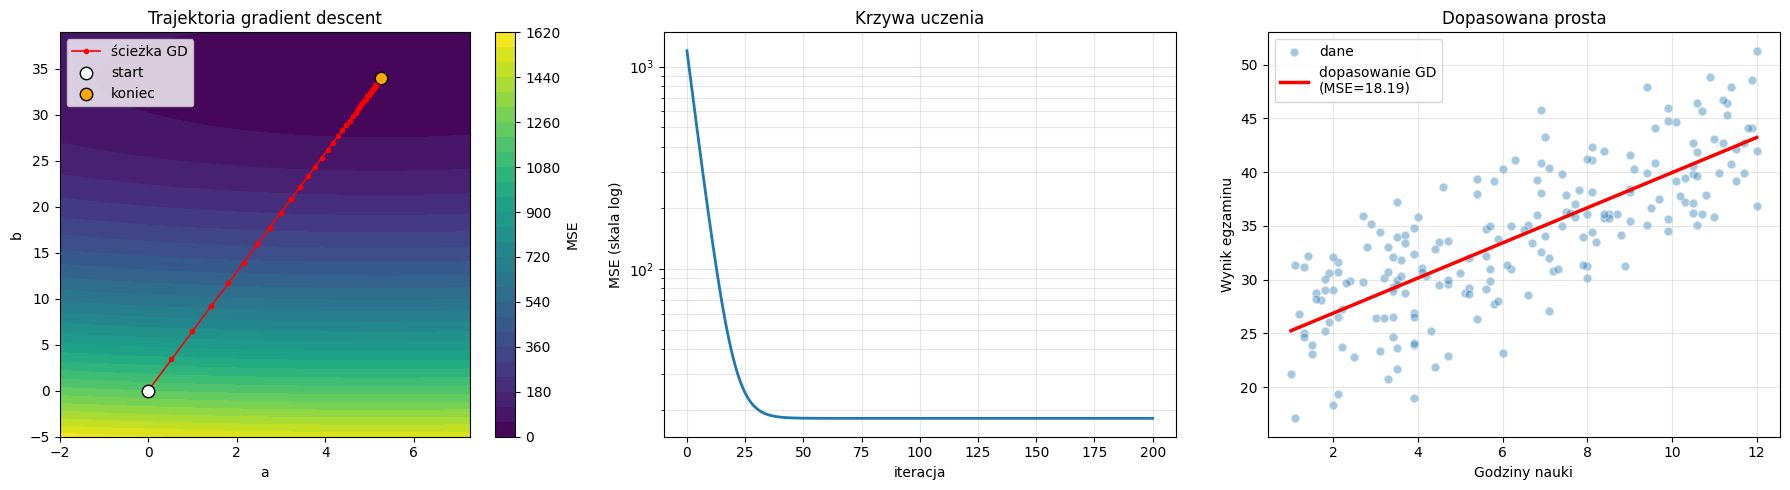

In [142]:
hist_a = np.array([h[0] for h in hist])
hist_b = np.array([h[1] for h in hist])
hist_l = np.array([h[2] for h in hist])

# Powierzchnia kosztu w zestandaryzowanej przestrzeni
a_g = np.linspace(hist_a.min() - 2, hist_a.max() + 2, 80)
b_g = np.linspace(hist_b.min() - 5, hist_b.max() + 5, 80)
Ag, Bg = np.meshgrid(a_g, b_g)
L = np.zeros_like(Ag)
for i in range(Ag.shape[0]):
    for j in range(Ag.shape[1]):
        L[i, j] = mse(y, predict(X_std_scaled, Ag[i, j], Bg[i, j]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Trajektoria na konturach kosztu
cs = axes[0].contourf(Ag, Bg, L, levels=30, cmap="viridis")
axes[0].plot(hist_a, hist_b, "o-", color="red", markersize=3, linewidth=1.2, label="ścieżka GD")
axes[0].scatter(
    [hist_a[0]], [hist_b[0]], color="white", s=80, edgecolor="black", zorder=5, label="start"
)
axes[0].scatter(
    [hist_a[-1]], [hist_b[-1]], color="orange", s=80, edgecolor="black", zorder=5, label="koniec"
)
axes[0].set_xlabel("a")
axes[0].set_ylabel("b")
axes[0].set_title("Trajektoria gradient descent")
axes[0].legend()
plt.colorbar(cs, ax=axes[0], label="MSE")

# (2) Krzywa uczenia
axes[1].plot(hist_l, linewidth=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("iteracja")
axes[1].set_ylabel("MSE (skala log)")
axes[1].set_title("Krzywa uczenia")
axes[1].grid(alpha=0.3, which="both")

# (3) Dopasowana linia w oryginalnej przestrzeni
axes[2].scatter(X, y, alpha=0.4, edgecolor="white", s=40, label="dane")
x_line_orig = np.linspace(X.min(), X.max(), 100)
x_line_std = (x_line_orig - X_mean) / X_std
axes[2].plot(
    x_line_orig,
    predict(x_line_std, a_opt, b_opt),
    color="red",
    linewidth=2.5,
    label=f"dopasowanie GD\n(MSE={hist_l[-1]:.2f})",
)
axes[2].set_xlabel("Godziny nauki")
axes[2].set_ylabel("Wynik egzaminu")
axes[2].set_title("Dopasowana prosta")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Uwaga o parametrach.** Współczynniki `a` i `b` powyżej dotyczą **zestandaryzowanego** $x$.
Aby przeliczyć je na oryginalną skalę:
$$a_\text{orig} = a / \sigma, \qquad b_\text{orig} = b - a \cdot \mu / \sigma$$


In [143]:
a_orig = a_opt / X_std
b_orig = b_opt - a_opt * X_mean / X_std
print(f"Model w oryginalnej skali: exam_score ≈ {a_orig:.3f} · hours_studied + {b_orig:.3f}")

Model w oryginalnej skali: exam_score ≈ 1.634 · hours_studied + 23.618


## 8. 🎛️ Interaktywna piaskownica

**Pobaw się suwakami** i zobacz, co się dzieje:

- **`learning_rate` zbyt duży** (np. 0.5) → algorytm „przeskakuje" minimum i może rozbiegać się.
- **`learning_rate` zbyt mały** (np. 0.001) → algorytm pełza w żółwim tempie.
- **`n_iter`** — ile kroków zrobi algorytm.
- **`a0, b0`** — punkt startowy. Spróbuj wystartować z różnych miejsc i zobacz, czy zawsze trafia w to samo minimum (powinno — bo MSE dla regresji liniowej jest **wypukłe**).


In [144]:
from ipywidgets import interact, FloatLogSlider, IntSlider, FloatSlider

# Pre-computed cost grid (do narysowania konturów jako tło)
_a_g = np.linspace(-3, 12, 100)
_b_g = np.linspace(-5, 50, 100)
_Ag, _Bg = np.meshgrid(_a_g, _b_g)
_L = np.zeros_like(_Ag)
for i in range(_Ag.shape[0]):
    for j in range(_Ag.shape[1]):
        _L[i, j] = mse(y, predict(X_std_scaled, _Ag[i, j], _Bg[i, j]))


def gd_demo(learning_rate=0.05, n_iter=50, a0=0.0, b0=0.0):
    a, b, h = gradient_descent(X_std_scaled, y, lr=learning_rate, n_iter=n_iter, a0=a0, b0=b0)
    ha = np.array([p[0] for p in h])
    hb = np.array([p[1] for p in h])
    hl = np.array([p[2] for p in h])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (1) Scatter + aktualna prosta
    axes[0].scatter(X, y, alpha=0.4, edgecolor="white", s=40)
    x_line_orig = np.linspace(X.min(), X.max(), 100)
    x_line_std = (x_line_orig - X_mean) / X_std
    axes[0].plot(x_line_orig, predict(x_line_std, a, b), color="red", linewidth=2.5)
    axes[0].set_xlabel("Godziny nauki")
    axes[0].set_ylabel("Wynik egzaminu")
    axes[0].set_title(f"Dopasowanie po {n_iter} iter.\nMSE = {hl[-1]:.2f}")
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(y.min() - 5, y.max() + 5)

    # (2) Kontury kosztu + trajektoria
    cs = axes[1].contourf(_Ag, _Bg, _L, levels=30, cmap="viridis")
    axes[1].plot(ha, hb, "o-", color="red", markersize=3, linewidth=1.2)
    axes[1].scatter(
        [ha[0]], [hb[0]], color="white", s=100, edgecolor="black", zorder=5, label="start"
    )
    axes[1].scatter(
        [ha[-1]], [hb[-1]], color="orange", s=100, edgecolor="black", zorder=5, label="koniec"
    )
    axes[1].set_xlabel("a")
    axes[1].set_ylabel("b")
    axes[1].set_title("Trajektoria w przestrzeni parametrów")
    axes[1].legend()
    plt.colorbar(cs, ax=axes[1], label="MSE")

    # (3) Krzywa uczenia
    finite = np.isfinite(hl) & (hl > 0)
    if finite.sum() > 1:
        axes[2].plot(np.where(finite)[0], hl[finite], linewidth=2)
        axes[2].set_yscale("log")
    else:
        axes[2].plot(hl, linewidth=2)
    axes[2].set_xlabel("iteracja")
    axes[2].set_ylabel("MSE (skala log)")
    axes[2].set_title("Krzywa uczenia")
    axes[2].grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()


interact(
    gd_demo,
    learning_rate=FloatLogSlider(value=0.05, base=10, min=-4, max=0, step=0.1, description="lr"),
    n_iter=IntSlider(value=50, min=1, max=500, step=1, description="iteracje"),
    a0=FloatSlider(value=0.0, min=-3, max=12, step=0.5, description="start a"),
    b0=FloatSlider(value=0.0, min=-5, max=50, step=1.0, description="start b"),
)

interactive(children=(FloatLogSlider(value=0.05, description='lr', max=0.0, min=-4.0), IntSlider(value=50, des…

<function __main__.gd_demo(learning_rate=0.05, n_iter=50, a0=0.0, b0=0.0)>

## 9. Podsumowanie

Co właśnie zobaczyliśmy:

1. **Gradient descent** to ogólny algorytm minimalizacji — działa wszędzie tam, gdzie potrafimy
 policzyć gradient funkcji kosztu. Tutaj minimum dało się wyliczyć analitycznie, ale dla
 bardziej skomplikowanych modeli (np. sieci neuronowych) **GD jest jedyną realną opcją**.
2. **Learning rate to najważniejszy hiperparametr**: za duży → rozbieżność, za mały → wolna
 zbieżność. Dobry domyślny zakres po standaryzacji wejścia to $10^{-2}$ do $10^{-1}$.
3. **Standaryzacja cech** drastycznie ułatwia uczenie — bez niej trzeba ręcznie szukać bardzo
 małego $\eta$, a algorytm staje się kapryśny.
4. Dla regresji liniowej z MSE funkcja kosztu jest **wypukła**, więc niezależnie od punktu
 startowego dochodzimy do tego samego globalnego minimum. Dla sieci neuronowych już tak
 nie jest — minimów lokalnych jest dużo.

### Pomysł na dalsze ćwiczenie
Dodaj drugą cechę (np. `sleep_hours` lub `previous_scores`) i zaimplementuj **regresję wielowymiarową**:
$$\hat{y} = a_1 x_1 + a_2 x_2 + b$$
Sam algorytm gradient descent prawie się nie zmienia — wystarczy dorzucić jeden update do listy.
